In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Business_Operations_Analyst_data.csv")

In [ ]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67


# Feature engineering

# Business Problem 1: Improve delivery Performance

In [ ]:
#Finding highest avg total time by warehouse

df['total_time'] = df['Order_Processing_Time'] + df['Shipping_Time_Days']

slow_warehouses = (
    df.groupby('Warehouse_ID')['total_time']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='avg_total_time')
)

slow_warehouses.head(10)

,Warehouse_ID,avg_total_time
0,WH382,11.727865
1,WH271,11.706867
2,WH449,11.440276
3,WH298,11.428036
4,WH013,11.116614
5,WH417,10.810684
6,WH398,10.792046
7,WH414,10.682687
8,WH350,10.499859
9,WH448,10.461434


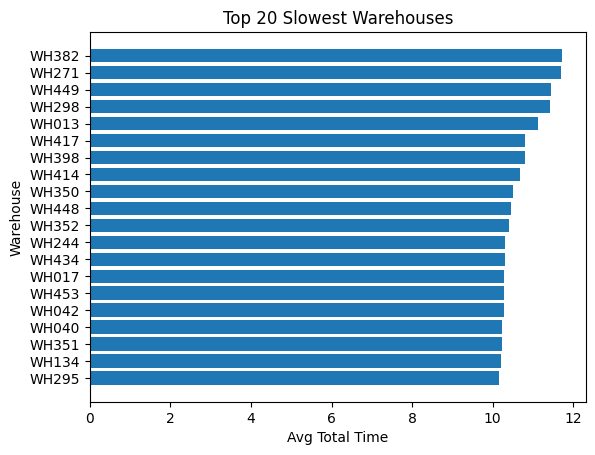

In [ ]:
#Vizualization of the slowest warehouses
# Top 20 slowest warehouses
top20_slow = slow_warehouses.head(20)

plt.figure()
plt.barh(top20_slow['Warehouse_ID'], top20_slow['avg_total_time'])
plt.gca().invert_yaxis()

plt.xlabel("Avg Total Time")
plt.ylabel("Warehouse")
plt.title("Top 20 Slowest Warehouses")

plt.show()

In [ ]:
df['sales_per_employee'] = df['Monthly_Sales'] / df['Employee_Count']

In [ ]:
emp_analysis = (
    df.groupby('Warehouse_ID')
    .agg(
        avg_processing=('Order_Processing_Time', 'mean'),
        avg_shipping=('Shipping_Time_Days', 'mean'),
        avg_sales=('Monthly_Sales', 'mean'),
        avg_employees=('Employee_Count', 'mean'),
        sales_per_emp=('sales_per_employee', 'mean')
    )
    .reset_index()
)

In [ ]:
emp_analysis['diff'] = emp_analysis['avg_processing'] - emp_analysis['avg_shipping']

emp_analysis['delay_type'] = np.where(
    emp_analysis['diff'] > 0,
    'Processing Delay',
    'Shipping Delay'
)

In [ ]:
top_processing = (
    emp_analysis[emp_analysis['delay_type'] == 'Processing Delay']
    .sort_values(by='diff', ascending=False)
    .head(5)
)

In [ ]:
efficient = emp_analysis.sort_values(by='avg_processing').head(10)

ideal_sales_per_emp = efficient['sales_per_emp'].mean()

In [ ]:
top_processing['required_employees'] = (
    top_processing['avg_sales'] / ideal_sales_per_emp
)

top_processing['employee_gap'] = (
    top_processing['required_employees'] - top_processing['avg_employees']
)

In [ ]:
top_processing[['Warehouse_ID',
                'avg_processing',
                'avg_sales',
                'avg_employees',
                'sales_per_emp',
                'required_employees',
                'employee_gap']]

,Warehouse_ID,avg_processing,avg_sales,avg_employees,sales_per_emp,required_employees,employee_gap
96,WH143,4.650513,4788.0,33.0,145.090909,23.475196,-9.524804
98,WH151,4.511183,7949.0,32.0,248.406250,38.973336,6.973336
139,WH220,4.272494,7295.0,48.0,151.979167,35.766824,-12.233176
156,WH251,4.231504,7620.0,84.0,90.714286,37.360274,-46.639726
213,WH349,4.436630,6012.0,33.0,178.641475,29.476374,-3.523626


In [ ]:
df['processing_per_unit'] = df['Order_Processing_Time'] / df['Monthly_Sales']

In [ ]:
processing_analysis = (
    df.groupby('Warehouse_ID')
    .agg(
        avg_processing=('Order_Processing_Time', 'mean'),
        avg_shipping=('Shipping_Time_Days', 'mean'),
        avg_sales=('Monthly_Sales', 'mean'),
        avg_employees=('Employee_Count', 'mean'),
        efficiency=('processing_per_unit', 'mean')
    )
    .reset_index()
)

In [ ]:
processing_analysis['diff'] = (
    processing_analysis['avg_processing'] - processing_analysis['avg_shipping']
)

processing_analysis['delay_type'] = np.where(
    processing_analysis['diff'] > 0,
    'Processing Delay',
    'Shipping Delay'
)

In [ ]:
top_processing = (
    processing_analysis[processing_analysis['delay_type'] == 'Processing Delay']
    .sort_values(by='diff', ascending=False)
    .head(5)
)

In [ ]:
efficient = processing_analysis.sort_values(by='avg_processing').head(10)

ideal_efficiency = efficient['efficiency'].mean()

In [ ]:
top_processing['efficiency_gap'] = (
    top_processing['efficiency'] - ideal_efficiency
)

In [ ]:
top_processing[[
    'Warehouse_ID',
    'avg_processing',
    'avg_employees',
    'avg_sales',
    'efficiency',
    'efficiency_gap'
]]

,Warehouse_ID,avg_processing,avg_employees,avg_sales,efficiency,efficiency_gap
96,WH143,4.650513,33.0,4788.0,0.000971,0.000816
98,WH151,4.511183,32.0,7949.0,0.000568,0.000412
139,WH220,4.272494,48.0,7295.0,0.000586,0.000430
156,WH251,4.231504,84.0,7620.0,0.000555,0.000400
213,WH349,4.436630,33.0,6012.0,0.000897,0.000742


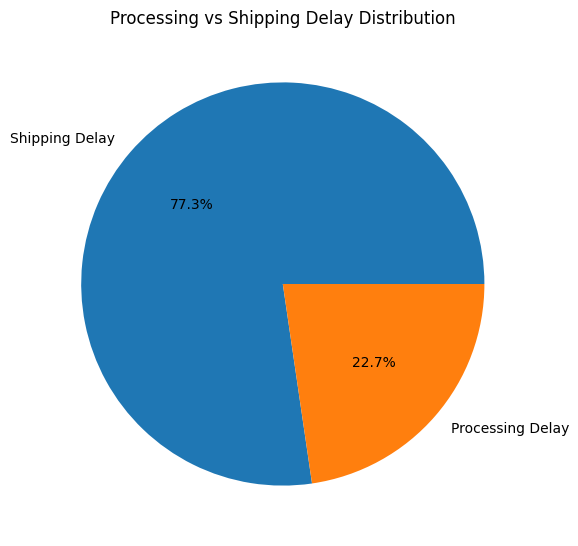

In [ ]:
# Count distribution
delay_counts = emp_analysis['delay_type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delay_counts.values,
    labels=delay_counts.index,
    autopct='%1.1f%%'
)

plt.title("Processing vs Shipping Delay Distribution")

plt.tight_layout()
plt.show()

In [ ]:
#Lead Time gap - Expected vs Actual
lead_time_analysis = (
    df.groupby('Warehouse_ID')
    .agg(
        avg_expected=('Lead_Time_Days', 'mean'),
        avg_actual=('total_time', 'mean')
    )
    .reset_index()
)
lead_time_analysis['gap'] = (
    lead_time_analysis['avg_actual'] - lead_time_analysis['avg_expected']
)
lead_time_analysis['delay_flag'] = np.where(
    lead_time_analysis['gap'] > 0,
    'Delayed',
    'On Time / Faster'
)

In [ ]:
lead_time_analysis.sort_values(by='gap', ascending=False)

,Warehouse_ID,avg_expected,avg_actual,gap,delay_flag
246,WH398,2.0,10.792046,8.792046,Delayed
214,WH350,2.0,10.499859,8.499859,Delayed
275,WH449,3.0,11.440276,8.440276,Delayed
11,WH017,2.0,10.282558,8.282558,Delayed
197,WH320,2.0,9.977135,7.977135,Delayed
...,...,...,...,...,...
18,WH027,9.0,2.830920,-6.169080,On Time / Faster
153,WH246,10.0,3.823741,-6.176259,On Time / Faster
114,WH182,8.0,1.655780,-6.344220,On Time / Faster
20,WH030,10.0,3.583968,-6.416032,On Time / Faster


# Solution for the delayed warehouses

In [ ]:
# Top 5 warehouses that are On Time / Faster
top_benchmark_wh = (
    lead_time_analysis[
        lead_time_analysis['delay_flag'] == 'On Time / Faster'
    ]
    .sort_values(by='gap')
    .head(5)
)

In [ ]:
# Benchmark details for those warehouses
benchmark_details = (
    df.merge(
        top_benchmark_wh[['Warehouse_ID']],
        on='Warehouse_ID',
        how='inner'
    )
    .groupby('Warehouse_ID')
    .agg(
        avg_shipping_time=('Shipping_Time_Days', 'mean'),
        avg_processing_time=('Order_Processing_Time', 'mean'),
        avg_employee_count=('Employee_Count', 'mean'),
        avg_total_time=('total_time', 'mean'),
        avg_lead_time=('Lead_Time_Days', 'mean')
    )
    .reset_index()
)

In [ ]:
# Sort by best-performing warehouses
benchmark_details = benchmark_details.sort_values(
    by='avg_total_time'
)
benchmark_details

,Warehouse_ID,avg_shipping_time,avg_processing_time,avg_employee_count,avg_total_time,avg_lead_time
2,WH031,1.0,0.568792,19.0,1.568792,10.0
3,WH182,1.0,0.655780,60.0,1.655780,8.0
0,WH027,2.0,0.830920,85.0,2.830920,9.0
1,WH030,1.0,2.583968,34.0,3.583968,10.0
4,WH246,2.0,1.823741,98.0,3.823741,10.0


In [ ]:
# Single benchmark values from top 5 best warehouses
# This can be used as a reference for other warehouses where the delay flag is "Delayed"
benchmark_values = {
    'benchmark_shipping_time': benchmark_details['avg_shipping_time'].mean(),
    'benchmark_processing_time': benchmark_details['avg_processing_time'].mean(),
    'benchmark_employee_count': benchmark_details['avg_employee_count'].mean(),
    'benchmark_total_time': benchmark_details['avg_total_time'].mean(),
    'benchmark_lead_time': benchmark_details['avg_lead_time'].mean()
}
benchmark_values 

{'benchmark_shipping_time': np.float64(1.4),
 'benchmark_processing_time': np.float64(1.2926402328147808),
 'benchmark_employee_count': np.float64(59.2),
 'benchmark_total_time': np.float64(2.6926402328147807),
 'benchmark_lead_time': np.float64(9.4)}

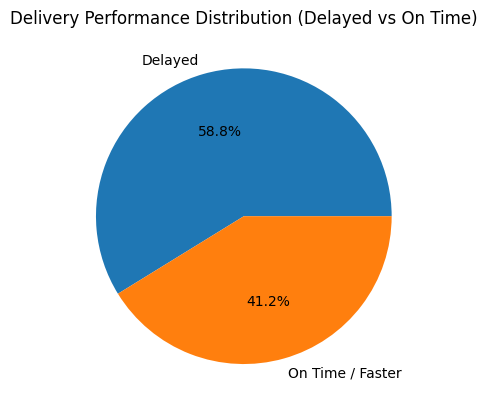

In [ ]:
delay_distribution = lead_time_analysis['delay_flag'].value_counts()
plt.figure()

plt.pie(
    delay_distribution,
    labels=delay_distribution.index,
    autopct='%1.1f%%'
)

plt.title("Delivery Performance Distribution (Delayed vs On Time)")

plt.show()

# Business Problem 2: Improve Inventory management 

In [ ]:
#demand vs supply gap
df['demand_gap'] = df['Demand_Forecast'] - df['Current_Stock']


In [ ]:
df['inventory_status'] = np.where(
    df['demand_gap'] > 0,
    'Shortage',
    'Overstock'
)
demand_gap_summary = df.groupby('Warehouse_ID')['demand_gap'].sum().reset_index()
demand_gap_summary.sort_values(by='demand_gap', ascending=False).head(10)

,Warehouse_ID,demand_gap
117,WH187,8031
146,WH232,6451
300,WH486,5916
128,WH202,5885
210,WH343,5685
179,WH290,5678
161,WH258,5549
147,WH233,5275
121,WH192,5239
95,WH141,5158


## If there is shortage in top warehouse then which category we want in that warehouses to not loss the upcoming sales

In [ ]:
# Top 10 shortage warehouses
top_shortage_warehouses = (
    demand_gap_summary.sort_values(by='demand_gap', ascending=False)
    .head(10)
)

In [ ]:
# Filter original data for only those warehouses
shortage_df = df.merge(
    top_shortage_warehouses[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
# Category-wise demand gap inside those warehouses
category_shortage = (
    shortage_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_demand=('Demand_Forecast', 'sum'),
        total_stock=('Current_Stock', 'sum')
    )
    .reset_index()
)

In [ ]:
# Calculate category demand gap
category_shortage['category_gap'] = (
    category_shortage['total_demand'] - category_shortage['total_stock']
)

In [ ]:
# Keep only shortage categories
category_shortage = category_shortage[
    category_shortage['category_gap'] > 0
]

In [ ]:
# Calculate contribution of each category to warehouse shortage
category_shortage['warehouse_total_gap'] = (
    category_shortage.groupby('Warehouse_ID')['category_gap']
    .transform('sum')
)

category_shortage['gap_percent'] = (
    category_shortage['category_gap'] /
    category_shortage['warehouse_total_gap']
) * 100

In [ ]:
# Sort so highest shortage category comes first for each warehouse
category_shortage = category_shortage.sort_values(
    by=['Warehouse_ID', 'category_gap'],
    ascending=[True, False]
)

In [ ]:
category_shortage[[
    'Warehouse_ID',
    'Product_Category',
    'category_gap',
    'gap_percent'
]]

,Warehouse_ID,Product_Category,category_gap,gap_percent
1,WH141,Furniture,4068,78.867778
0,WH141,Automotive,1090,21.132222
4,WH187,Groceries,3497,43.543768
2,WH187,Apparel,2850,35.487486
3,WH187,Electronics,1684,20.968746
5,WH192,Electronics,3185,60.794045
6,WH192,Furniture,2054,39.205955
8,WH202,Electronics,3947,67.068819
7,WH202,Automotive,1938,32.931181
11,WH232,Groceries,3335,51.697411


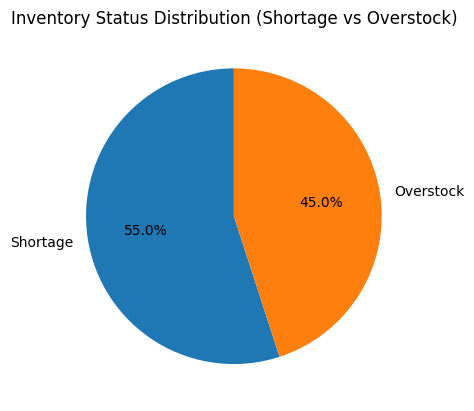

In [ ]:
demand_dist = df['inventory_status'].value_counts()

plt.figure()

plt.pie(
    demand_dist.values,
    labels=demand_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Inventory Status Distribution (Shortage vs Overstock)")
plt.show()

In [ ]:
#Inventory utilization 
df['warehouse_utilization'] = (
    df['Current_Stock'] * 1.0 / df['Warehouse_Capacity']
)
df['utilization_category'] = pd.cut(
    df['warehouse_utilization'],
    bins=[0, 0.1, 0.25, 0.4, 1],
    labels=['Very Low', 'Low', 'Moderate', 'High']
)

In [ ]:
util_summary = df['utilization_category'].value_counts()
util_summary

utilization_category
Very Low    283
Low         178
Moderate     32
High          7
Name: count, dtype: int64

## Solution : which are the warehouses that cross the median sales and their utilization is moderate and high.
This are warehouses with maximum outcome.

In [ ]:
sales_threshold = df['Monthly_Sales'].median()

In [ ]:
filtered_warehouses = df[
    (df['utilization_category'].isin(['High', 'Moderate'])) &
    (df['Monthly_Sales'] > sales_threshold)
]

In [ ]:
result = filtered_warehouses[['Warehouse_ID', 'utilization_category', 'Monthly_Sales']].drop_duplicates()

In [ ]:
result = result.sort_values(by='Monthly_Sales', ascending=False)

In [ ]:
result

,Warehouse_ID,utilization_category,Monthly_Sales
157,WH097,Moderate,9762
359,WH092,Moderate,9398
112,WH280,Moderate,7808
71,WH071,Moderate,7782
116,WH375,High,7625
54,WH192,Moderate,7397
209,WH165,High,7346
370,WH259,Moderate,7125
24,WH196,Moderate,7111
278,WH104,Moderate,7022


## IS there any employee gap in this warehouses to prevent future problems

In [ ]:
# Top outcome warehouses
top_outcome_wh = (
    filtered_warehouses.groupby('Warehouse_ID')
    .agg(
        avg_monthly_sales=('Monthly_Sales', 'mean'),
        utilization_category=('utilization_category', 'first'),
        avg_employee_count=('Employee_Count', 'mean')
    )
    .reset_index()
)

In [ ]:
# Sales handled per employee in these warehouses
top_outcome_wh['sales_per_employee'] = (
    top_outcome_wh['avg_monthly_sales'] /
    top_outcome_wh['avg_employee_count']
)

In [ ]:
# Ideal benchmark from best-performing warehouses
ideal_sales_per_employee = top_outcome_wh['sales_per_employee'].median()

In [ ]:
# Required / ideal employee count for each warehouse
top_outcome_wh['ideal_employee_count'] = (
    top_outcome_wh['avg_monthly_sales'] /
    ideal_sales_per_employee
)

In [ ]:
# Gap between actual and ideal employee count
top_outcome_wh['employee_gap'] = (
    top_outcome_wh['avg_employee_count'] -
    top_outcome_wh['ideal_employee_count']
)

In [ ]:
# Sort by largest employee gap
top_outcome_wh = top_outcome_wh.sort_values(
    by='employee_gap',
    ascending=False
)

In [ ]:
top_outcome_wh[[
    'Warehouse_ID',
    'utilization_category',
    'avg_monthly_sales',
    'avg_employee_count',
    'ideal_employee_count',
    'employee_gap'
]]

,Warehouse_ID,utilization_category,avg_monthly_sales,avg_employee_count,ideal_employee_count,employee_gap
9,WH196,Moderate,7111.0,84.0,56.418095,27.581905
3,WH088,High,6480.0,75.0,51.411792,23.588208
15,WH440,Moderate,5491.0,61.0,43.565147,17.434853
0,WH002,Moderate,5528.0,57.0,43.858702,13.141298
12,WH280,Moderate,7808.0,70.0,61.948036,8.051964
4,WH092,Moderate,9398.0,78.0,74.562967,3.437033
11,WH259,Moderate,7125.0,59.0,56.529170,2.470830
7,WH165,High,7346.0,59.0,58.282566,0.717434
1,WH071,Moderate,7782.0,61.0,61.741754,-0.741754
14,WH375,High,7625.0,52.0,60.496129,-8.496129


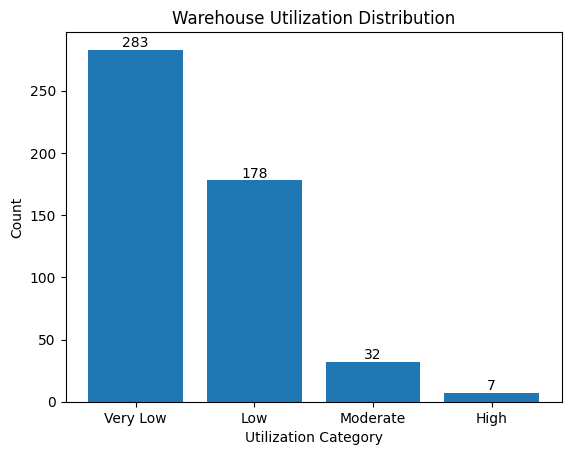

In [ ]:
util_dist = df['utilization_category'].value_counts()

plt.figure()

bars = plt.bar(util_dist.index, util_dist.values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.xlabel("Utilization Category")
plt.ylabel("Count")
plt.title("Warehouse Utilization Distribution")

plt.show()

In [ ]:
#Backorder quantities per warehouses
backorder_summary = (
    df.groupby('Warehouse_ID')['Backorder_Quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_warehouses = backorder_summary.head(10)

In [ ]:
backorder_summary.head(10)

,Warehouse_ID,Backorder_Quantity
0,WH033,1174
1,WH286,850
2,WH326,767
3,WH092,746
4,WH100,733
5,WH488,698
6,WH232,666
7,WH390,655
8,WH239,635
9,WH093,595


In [ ]:
filtered_df = df.merge(
    top_warehouses[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
damage_category = (
    filtered_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_damaged=('Damaged_Goods', 'sum')
    )
    .reset_index()
)

In [ ]:
damage_category_sorted = damage_category.sort_values(
    by=['Warehouse_ID', 'total_damaged'],
    ascending=[True, False]
)

In [ ]:
damage_category_sorted['Warehouse_ID'] = damage_category_sorted['Warehouse_ID'].mask(
    damage_category_sorted['Warehouse_ID'].duplicated()
)

In [ ]:
damage_category_sorted

,Warehouse_ID,Product_Category,total_damaged
2,WH033,Electronics,80
0,NaN,Apparel,52
1,NaN,Automotive,14
6,WH092,Groceries,41
4,NaN,Electronics,40
3,NaN,Automotive,19
5,NaN,Furniture,13
9,WH093,Furniture,44
7,NaN,Apparel,36
8,NaN,Automotive,27


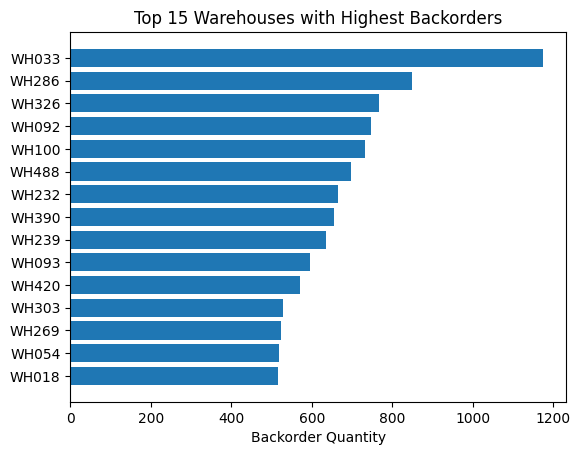

In [ ]:
top_backorders = backorder_summary.head(15)

plt.figure()

plt.barh(top_backorders['Warehouse_ID'], top_backorders['Backorder_Quantity'])
plt.gca().invert_yaxis()

plt.xlabel("Backorder Quantity")
plt.title("Top 15 Warehouses with Highest Backorders")

plt.show()

In [ ]:
#Inventory turnover
df['inventory_turnover'] = (
    df['Monthly_Sales'] * 1.0 / df['Current_Stock']
)
df['turnover_category'] = pd.cut(
    df['inventory_turnover'],
    bins=[-np.inf, 0.5, 1, 2, 5, np.inf],
    labels=[
        'Dead Stock',
        'Slow Moving',
        'Healthy',
        'Fast Moving',
        'Very Fast'
    ]
)

In [ ]:
turnover_summary = df['turnover_category'].value_counts()
turnover_summary


turnover_category
Fast Moving    180
Healthy        162
Slow Moving     67
Very Fast       66
Dead Stock      25
Name: count, dtype: int64

## Solution 1: at which locations Dead stock conditions are there

In [ ]:
dead_stock_df = df[df['turnover_category'] == 'Dead Stock']

In [ ]:
dead_stock_locations = dead_stock_df[['Warehouse_ID', 'Location']].drop_duplicates()

In [ ]:
location_summary = (
    dead_stock_locations.groupby('Location')['Warehouse_ID']
    .nunique()
    .reset_index(name='dead_stock_warehouses')
    .sort_values(by='dead_stock_warehouses', ascending=False)
)
location_summary

,Location,dead_stock_warehouses
8,Seattle,5
1,Dallas,4
6,New York,3
5,Miami,3
4,Los Angeles,3
3,Houston,2
2,Denver,2
7,San Francisco,2
0,Chicago,1


## Solution 2 For fast moving and very fast warehouses

In [ ]:
fast_moving_df = df[
    df['turnover_category'].isin(['Fast Moving', 'Very Fast'])
]

In [ ]:
avg_sales = (
    fast_moving_df.groupby('Warehouse_ID')['Monthly_Sales']
    .mean()
    .reset_index(name='avg_monthly_sales')
)

In [ ]:
avg_sales = avg_sales.sort_values(by='avg_monthly_sales', ascending=False)

In [ ]:
avg_sales #keeping current stock of fast moving and very fast warehouses leads to lower the risk of stockouts and lost sales, while also optimizing inventory levels to reduce holding costs.

,Warehouse_ID,avg_monthly_sales
58,WH131,9931.0
119,WH304,9928.0
123,WH319,9874.0
187,WH491,9864.0
80,WH191,9842.0
...,...,...
27,WH063,1845.0
162,WH430,1825.0
59,WH134,1756.0
133,WH351,1694.0


## Solution: Setting benchmark for the Dead stock and slow moving warehouses from healthy warehouses

In [ ]:
# Only healthy inventory warehouses
healthy_df = df[df['turnover_category'] == 'Healthy']

In [ ]:
# Total stock by category inside healthy warehouses
healthy_category_stock = (
    healthy_df.groupby('Product_Category')
    .agg(
        total_stock=('Current_Stock', 'sum')
    )
    .reset_index()
)

In [ ]:
# Total stock across all categories
total_stock = healthy_category_stock['total_stock'].sum()

In [ ]:
# Percentage share of each category
healthy_category_stock['stock_percent'] = (
    healthy_category_stock['total_stock'] / total_stock
) * 100

In [ ]:
# Sort from highest stock share to lowest
healthy_category_stock = healthy_category_stock.sort_values(
    by='stock_percent',
    ascending=False
)

In [ ]:
healthy_category_stock[['Product_Category', 'stock_percent']]

,Product_Category,stock_percent
4,Groceries,29.064673
0,Apparel,23.768693
2,Electronics,17.172858
3,Furniture,16.326084
1,Automotive,13.667692


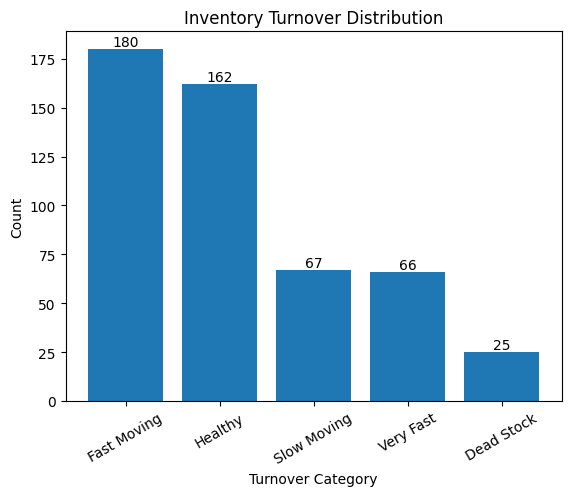

In [ ]:
turnover_dist = df['turnover_category'].value_counts()

plt.figure()

bars = plt.bar(turnover_dist.index, turnover_dist.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )
    
plt.xlabel("Turnover Category")
plt.ylabel("Count")
plt.title("Inventory Turnover Distribution")

plt.xticks(rotation=30)
plt.show()

In [ ]:
#Damaged goods rate per warehouse
df['damage_rate'] = (
    df['Damaged_Goods'] * 1.0 / df['Current_Stock']
)

In [ ]:
damage_summary = (
    df.groupby('Warehouse_ID')['damage_rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

damage_summary.head(5)

,Warehouse_ID,damage_rate
0,WH063,0.096339
1,WH442,0.091912
2,WH134,0.080756
3,WH467,0.078212
4,WH223,0.064725


## Solution : for the category that damages most in top warehouses with highest damaged rate

In [ ]:
damage_summary = (
    df.groupby('Warehouse_ID')['damage_rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_warehouses = damage_summary.head(5)

In [ ]:
filtered_df = df.merge(
    top_warehouses[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
category_damage_summary = (
    filtered_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_damage=('Damaged_Goods', 'sum'),
        total_stock=('Current_Stock', 'sum')
    )
    .reset_index()
)

In [ ]:
category_damage_summary['damage_rate'] = (
    category_damage_summary['total_damage'] / category_damage_summary['total_stock']
)

In [ ]:
category_damage_summary = category_damage_summary.sort_values(
    by=['Warehouse_ID', 'damage_rate'],
    ascending=[True, False]
)

In [ ]:
category_damage_summary[['Warehouse_ID', 'Product_Category', 'damage_rate']]

,Warehouse_ID,Product_Category,damage_rate
0,WH063,Furniture,0.096339
1,WH134,Furniture,0.080756
2,WH223,Groceries,0.064725
3,WH442,Groceries,0.091912
4,WH467,Electronics,0.078212


## Business Problem 3: Demand Forecasting

In [ ]:
#Forecast vs actual demand vs sales
df['demand_gap'] = df['Demand_Forecast'] - df['Monthly_Sales']


In [ ]:
#Forecast error
df['forecast_error'] = df['Demand_Forecast'] - df['Monthly_Sales']

df['forecast_category'] = np.select(
    [
        df['forecast_error'] > 0,
        df['forecast_error'] < 0
    ],
    [
        'Overestimate (Unmet Demand)',
        'Under-Forecast'
    ],
    default='Accurate'
)

## Solution : if backorder is the reason

In [ ]:
# Warehouses already categorized as unmet demand
unmet_demand_df = df[df['forecast_category'] == 'Overestimate (Unmet Demand)']

In [ ]:
# Total unmet demand gap per warehouse
unmet_summary = (
    unmet_demand_df.groupby('Warehouse_ID')
    .agg(
        total_forecast_gap=('forecast_error', 'sum')
    )
    .reset_index()
    .sort_values(by='total_forecast_gap', ascending=False)
)

In [ ]:
# Top 5 warehouses with highest unmet demand
top_unmet_warehouses = unmet_summary.head(5)

In [ ]:
# Backorder quantity for those top unmet demand warehouses
backorder_unmet = (
    df.merge(top_unmet_warehouses[['Warehouse_ID']], on='Warehouse_ID', how='inner')
    .groupby('Warehouse_ID')
    .agg(
        total_backorders=('Backorder_Quantity', 'sum'),
        total_unmet_gap=('forecast_error', 'sum')
    )
    .reset_index()
    .sort_values(by='total_backorders', ascending=False)
)

In [ ]:
backorder_unmet

,Warehouse_ID,total_backorders,total_unmet_gap
1,WH390,655,3508
4,WH493,364,3720
3,WH490,353,4492
2,WH395,179,4036
0,WH343,111,4142


## Solution 2: Due to stock out risk

In [ ]:
# Top 3 warehouses with highest unmet demand
top_unmet_3 = (
    unmet_summary.head(5)
)

In [ ]:
# Stockout risk for those warehouses
stockout_risk_summary = (
    df.merge(top_unmet_3[['Warehouse_ID']], on='Warehouse_ID', how='inner')
    .groupby('Warehouse_ID')
    .agg(
        avg_stockout_risk=('Stockout_Risk', 'mean'),
        total_forecast_gap=('forecast_error', 'sum'),
        total_backorders=('Backorder_Quantity', 'sum')
    )
    .reset_index()
    .sort_values(by='avg_stockout_risk', ascending=False)
)

In [ ]:
stockout_risk_summary

,Warehouse_ID,avg_stockout_risk,total_forecast_gap,total_backorders
0,WH343,23.000000,4142,111
1,WH390,19.666667,3508,655
3,WH490,12.000000,4492,353
4,WH493,11.500000,3720,364
2,WH395,6.000000,4036,179


## Solution 3: Customer rating can be issue

In [ ]:
# Warehouses already categorized as Under-Forecast
underforecast_df = df[df['forecast_category'] == 'Under-Forecast']

In [ ]:
# Total under-forecast gap per warehouse
underforecast_summary = (
    underforecast_df.groupby('Warehouse_ID')
    .agg(
        total_underforecast_gap=('forecast_error', 'sum')
    )
    .reset_index()
    .sort_values(by='total_underforecast_gap')
)

In [ ]:
# Top warehouses with biggest under-forecasting problem
top_underforecast_warehouses = underforecast_summary.head(5)

In [ ]:
# Customer rating analysis for those warehouses
customer_rating_summary = (
    df.merge(top_underforecast_warehouses[['Warehouse_ID']], on='Warehouse_ID', how='inner')
    .groupby('Warehouse_ID')
    .agg(
        avg_customer_rating=('Customer_Rating', 'mean'),
        avg_monthly_sales=('Monthly_Sales', 'mean'),
        total_underforecast_gap=('forecast_error', 'sum')
    )
    .reset_index()
    .sort_values(by='avg_customer_rating', ascending=False)
)

In [ ]:
customer_rating_summary

,Warehouse_ID,avg_customer_rating,avg_monthly_sales,total_underforecast_gap
2,WH344,3.867811,8978.500000,-16589
0,WH033,3.654787,7698.800000,-25169
1,WH286,3.231700,5768.200000,-17337
3,WH361,3.226221,7532.666667,-16575
4,WH458,2.800264,6501.333333,-15612


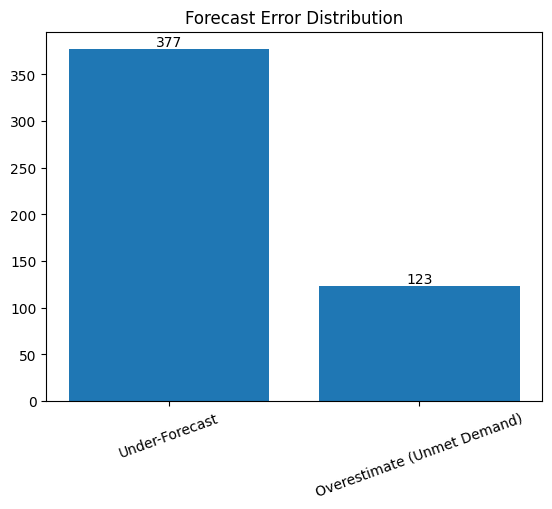

In [ ]:
#ploting the forecast error distribution
forecast_dist = df['forecast_category'].value_counts()

plt.figure()

bars = plt.bar(forecast_dist.index, forecast_dist.values)

# Add counts
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height),
             ha='center', va='bottom')

plt.title("Forecast Error Distribution")
plt.xticks(rotation=20)

plt.show()

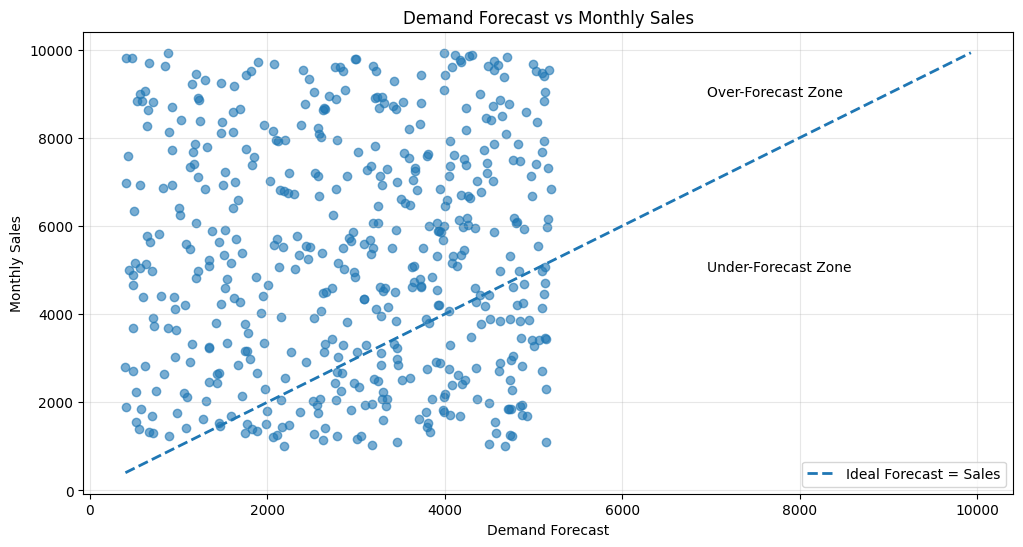

In [ ]:
plt.figure(figsize=(12,6))

# Scatter plot
plt.scatter(
    df['Demand_Forecast'],
    df['Monthly_Sales'],
    alpha=0.6
)

# Ideal line
min_val = min(df['Demand_Forecast'].min(), df['Monthly_Sales'].min())
max_val = max(df['Demand_Forecast'].max(), df['Monthly_Sales'].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Ideal Forecast = Sales'
)

# Add labels and title
plt.xlabel("Demand Forecast")
plt.ylabel("Monthly Sales")
plt.title("Demand Forecast vs Monthly Sales")

# Add interpretation zones
plt.text(
    max_val * 0.7,
    max_val * 0.9,
    'Over-Forecast Zone',
    fontsize=10
)

plt.text(
    max_val * 0.7,
    max_val * 0.5,
    'Under-Forecast Zone',
    fontsize=10
)

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
#Accuracy
df['accuracy'] = df['Monthly_Sales'] / df['Demand_Forecast']

df['accuracy_category'] = pd.cut(
    df['accuracy'],
    bins=[-np.inf, 0.9, 1, 1.2, 2, np.inf],
    labels=[
        'Underperforming',
        'Slightly Under',
        'Accurate',
        'Overperforming',
        'Highly Overperforming'
    ]
)

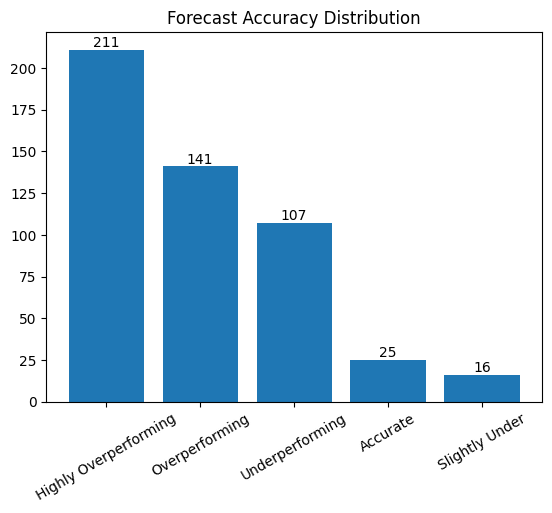

In [ ]:
#ploting the accuracy distribution
accuracy_dist = df['accuracy_category'].value_counts()

plt.figure()

bars = plt.bar(accuracy_dist.index, accuracy_dist.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height),
             ha='center', va='bottom')

plt.title("Forecast Accuracy Distribution")
plt.xticks(rotation=30)

plt.show()

## Solution: if warehouse is Highly overperforming then which category is performing well

In [ ]:
# Warehouses with Highly Overperforming accuracy
highly_overperforming_wh = df[
    df['accuracy_category'] == 'Highly Overperforming'
]

In [ ]:
# Filter original data for those warehouses only
filtered_df = df.merge(
    highly_overperforming_wh[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
# Product category sales inside those warehouses
category_sales = (
    filtered_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

In [ ]:
# Sort so highest-selling category comes first for each warehouse
category_sales = category_sales.sort_values(
    by=['Warehouse_ID', 'total_sales'],
    ascending=[True, False]
)

In [ ]:
category_sales

,Warehouse_ID,Product_Category,total_sales
0,WH002,Electronics,5528
2,WH005,Furniture,4844
1,WH005,Apparel,2701
4,WH007,Electronics,7138
3,WH007,Apparel,6401
...,...,...,...
262,WH491,Automotive,10152
264,WH492,Furniture,5005
265,WH492,Groceries,1004
266,WH494,Automotive,8588


In [ ]:
top_category_per_wh = (
    category_sales.groupby('Warehouse_ID')
    .head(1)
    .reset_index(drop=True)
)

In [ ]:
top_category_per_wh[['Warehouse_ID', 'Product_Category', 'total_sales']]

,Warehouse_ID,Product_Category,total_sales
0,WH002,Electronics,5528
1,WH005,Furniture,4844
2,WH007,Electronics,7138
3,WH009,Electronics,16824
4,WH012,Electronics,14367
...,...,...,...
166,WH489,Apparel,5090
167,WH491,Groceries,19728
168,WH492,Furniture,5005
169,WH494,Automotive,8588


In [ ]:
#Category wise sales
category_sales = (
    df.groupby('Product_Category')['Monthly_Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales.head()

,Product_Category,Monthly_Sales
0,Apparel,564991
1,Electronics,560057
2,Groceries,541821
3,Furniture,516458
4,Automotive,484459


## Solution: who was the supplier

In [ ]:
# Supplier contribution inside each product category
category_supplier_sales = (
    df.groupby(['Product_Category', 'Supplier_ID'])
    .agg(
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

In [ ]:
# Sort so highest-selling supplier appears first within each category
category_supplier_sales = category_supplier_sales.sort_values(
    by=['Product_Category', 'total_sales'],
    ascending=[True, False]
)

In [ ]:
category_supplier_sales

,Product_Category,Supplier_ID,total_sales
74,Apparel,S801,11392
7,Apparel,S201,10117
96,Apparel,S952,9874
45,Apparel,S532,9816
33,Apparel,S452,9800
...,...,...,...
460,Groceries,S921,1393
409,Groceries,S436,1248
408,Groceries,S434,1225
454,Groceries,S844,1150


## Top Suppliers

In [ ]:
top_supplier_per_category = (
    category_supplier_sales.groupby('Product_Category')
    .head(1)
    .reset_index(drop=True)
)
top_supplier_per_category

,Product_Category,Supplier_ID,total_sales
0,Apparel,S801,11392
1,Automotive,S188,9962
2,Electronics,S464,14382
3,Furniture,S372,14024
4,Groceries,S355,18379


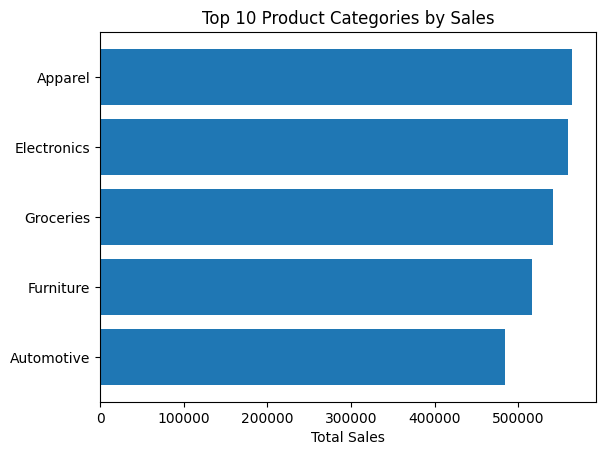

In [ ]:
top_categories = category_sales.head(10)

plt.figure()

plt.barh(top_categories['Product_Category'], top_categories['Monthly_Sales'])
plt.gca().invert_yaxis()

plt.xlabel("Total Sales")
plt.title("Top 10 Product Categories by Sales")

plt.show()

In [ ]:
#Location based demand and sales patterns
location_gap = (
    df.groupby('Location')
    .agg(
        total_demand=('Demand_Forecast', 'sum'),
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)
location_gap['gap'] = location_gap['total_demand'] - location_gap['total_sales']

threshold = location_gap['gap'].mean()

location_gap['demand_status'] = np.where(
    location_gap['gap'] > threshold,
    'Unmet Demand Location',
    'Overstock / Low Demand'
)

In [ ]:
location_gap.sort_values(by='gap', ascending=False)

,Location,total_demand,total_sales,gap,demand_status
9,Seattle,125377,190863,-65486,Unmet Demand Location
4,Houston,147430,248736,-101306,Unmet Demand Location
5,Los Angeles,148083,254419,-106336,Unmet Demand Location
2,Dallas,152023,267824,-115801,Unmet Demand Location
3,Denver,137814,255713,-117899,Unmet Demand Location
6,Miami,174304,297266,-122962,Overstock / Low Demand
8,San Francisco,148359,279076,-130717,Overstock / Low Demand
7,New York,155107,287440,-132333,Overstock / Low Demand
1,Chicago,114856,261529,-146673,Overstock / Low Demand
0,Atlanta,175172,324920,-149748,Overstock / Low Demand


In [ ]:
location_gap['demand_status'].value_counts()

demand_status
Overstock / Low Demand    5
Unmet Demand Location     5
Name: count, dtype: int64

In [ ]:
#Demand sales alignment 
#Thresholds for demand and sales
median_demand = df['Demand_Forecast'].median()
median_sales = df['Monthly_Sales'].median()

print(f"Median Demand: {median_demand}")
print(f"Median Sales: {median_sales}")

Median Demand: 3094.0
Median Sales: 5234.0


In [ ]:
#now categorizing them into zones based on demand and sales
df['demand_sales_zone'] = np.select(
    [
        (df['Demand_Forecast'] > median_demand) & (df['Monthly_Sales'] > median_sales),
        (df['Demand_Forecast'] > median_demand) & (df['Monthly_Sales'] <= median_sales),
        (df['Demand_Forecast'] <= median_demand) & (df['Monthly_Sales'] > median_sales)
    ],
    [
        'Future Demand Zone',
        'Unmet Demand Zone',
        'Under-Forecast Zone'
    ],
    default='Low Demand Zone'
)

## Solution: top warehouses with highes sold product cateogory in future demand zone

In [ ]:
# Warehouses in Future Demand Zone
future_demand_df = df[df['demand_sales_zone'] == 'Future Demand Zone']

In [ ]:
# Top 5 warehouses based on total monthly sales
top_future_warehouses = (
    future_demand_df.groupby('Warehouse_ID')
    .agg(
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
    .head(5)
)

In [ ]:
# Filter original future demand data for only those top warehouses
filtered_future_df = future_demand_df.merge(
    top_future_warehouses[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
# Category sales inside those warehouses
future_category_sales = (
    filtered_future_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

In [ ]:
# Sort so highest-selling category appears first for each warehouse
future_category_sales = future_category_sales.sort_values(
    by=['Warehouse_ID', 'total_sales'],
    ascending=[True, False]
)
future_category_sales

,Warehouse_ID,Product_Category,total_sales
1,WH033,Automotive,8936
0,WH033,Apparel,7580
2,WH054,Electronics,17076
3,WH199,Electronics,17076
5,WH233,Furniture,15775
6,WH233,Groceries,9664
4,WH233,Apparel,7676
8,WH434,Electronics,9752
7,WH434,Automotive,9095


In [ ]:
top_future_category = (
    future_category_sales.groupby('Warehouse_ID')
    .head(1)
    .reset_index(drop=True)
)
top_future_category

,Warehouse_ID,Product_Category,total_sales
0,WH033,Automotive,8936
1,WH054,Electronics,17076
2,WH199,Electronics,17076
3,WH233,Furniture,15775
4,WH434,Electronics,9752


## Solution for low demand zone warehouses and their respective locations

In [ ]:
# Warehouses in Low Demand Zone
low_demand_df = df[df['demand_sales_zone'] == 'Low Demand Zone']

In [ ]:
# Top low demand warehouses based on lowest total sales
top_low_demand = (
    low_demand_df.groupby('Warehouse_ID')
    .agg(
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
    .sort_values(by='total_sales')
    .head(10)
)

In [ ]:
# Get location and supplier information for those warehouses
low_demand_details = (
    low_demand_df.merge(
        top_low_demand[['Warehouse_ID']],
        on='Warehouse_ID',
        how='inner'
    )
    .groupby('Warehouse_ID')
    .agg(
        Location=('Location', 'first'),
        Supplier_ID=('Supplier_ID', 'first'),
        total_sales=('Monthly_Sales', 'sum'),
        total_demand=('Demand_Forecast', 'sum')
    )
    .reset_index()
    .sort_values(by='total_sales')
)
low_demand_details

,Warehouse_ID,Location,Supplier_ID,total_sales,total_demand
4,WH205,Houston,S844,1150,2629
7,WH370,Houston,S744,1163,3011
5,WH302,Los Angeles,S872,1220,2066
3,WH190,Dallas,S434,1225,898
1,WH090,Seattle,S775,1239,3056
6,WH322,Chicago,S134,1245,2782
0,WH078,San Francisco,S436,1248,2107
8,WH391,Miami,S102,1288,2527
2,WH093,Miami,S411,1304,717
9,WH499,Seattle,S254,1314,1747


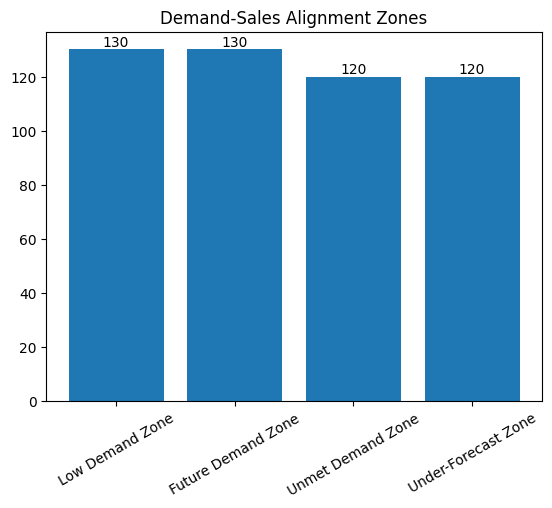

In [ ]:
#Distribution of demand-sales alignment zones
zone_dist = df['demand_sales_zone'].value_counts()

plt.figure()

bars = plt.bar(zone_dist.index, zone_dist.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height),
             ha='center', va='bottom')

plt.title("Demand-Sales Alignment Zones")
plt.xticks(rotation=30)

plt.show()

## Business Problem 4: Cost optimization

In [ ]:
#Total cost feature
df['total_cost'] = df['Storage_Cost'] + df['Transportation_Cost']

In [ ]:
cost_summary = (
    df.groupby('Warehouse_ID')['total_cost']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

cost_summary.head(10)

,Warehouse_ID,total_cost
0,WH033,97388
1,WH286,88071
2,WH162,85377
3,WH428,82782
4,WH361,81661
5,WH390,80162
6,WH092,74453
7,WH326,72465
8,WH054,71391
9,WH420,71002


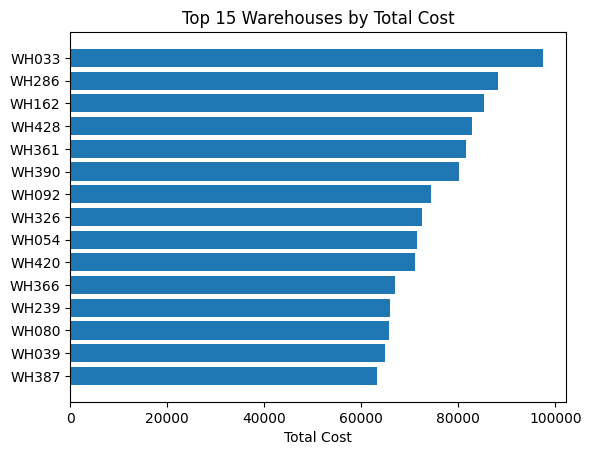

In [ ]:
top_cost = cost_summary.head(15)

plt.figure()

plt.barh(top_cost['Warehouse_ID'], top_cost['total_cost'])
plt.gca().invert_yaxis()

plt.xlabel("Total Cost")
plt.title("Top 15 Warehouses by Total Cost")

plt.show()

In [ ]:
#Cost ditribution - where money flows more for each warehouse
cost_dist = (
    df.groupby('Warehouse_ID')
    .agg(
        avg_storage=('Storage_Cost', 'mean'),
        avg_transport=('Transportation_Cost', 'mean')
    )
    .reset_index()
)

cost_dist['diff'] = cost_dist['avg_storage'] - cost_dist['avg_transport']

cost_dist['dominant_cost'] = np.where(
    cost_dist['diff'] > 0,
    'Storage Cost High',
    'Transportation Cost High'
)

## Solution for the storage cost dominance

In [ ]:
# Warehouses where storage cost is dominant
storage_cost_high = cost_dist[
    cost_dist['dominant_cost'] == 'Storage Cost High'
]
storage_cost_high.sort_values(by='avg_storage', ascending=False).head(5)

,Warehouse_ID,avg_storage,avg_transport,diff,dominant_cost
199,WH324,19929.0,14181.0,5748.0,Storage Cost High
244,WH396,19812.0,13221.0,6591.0,Storage Cost High
31,WH043,19635.0,13095.0,6540.0,Storage Cost High
283,WH462,19529.0,7146.0,12383.0,Storage Cost High
29,WH041,19518.0,6490.0,13028.0,Storage Cost High


In [ ]:
# Merge with original data to get location and utilization
storage_cost_details = (
    df.merge(
        storage_cost_high[['Warehouse_ID']],
        on='Warehouse_ID',
        how='inner'
    )
    .groupby('Warehouse_ID')
    .agg(
        Location=('Location', 'first'),
        avg_storage_cost=('Storage_Cost', 'mean'),
        avg_transport_cost=('Transportation_Cost', 'mean'),
        avg_current_stock=('Current_Stock', 'mean'),
        avg_capacity=('Warehouse_Capacity', 'mean')
    )
    .reset_index()
)

In [ ]:
# Calculate warehouse utilization
storage_cost_details['warehouse_utilization'] = (
    storage_cost_details['avg_current_stock'] /
    storage_cost_details['avg_capacity']
) * 100

In [ ]:
# Sort by highest storage cost
storage_cost_details = storage_cost_details.sort_values(
    by='avg_storage_cost',
    ascending=False
)

In [ ]:
storage_cost_details[[
    'Warehouse_ID',
    'Location',
    'avg_storage_cost',
    'warehouse_utilization'
]]

,Warehouse_ID,Location,avg_storage_cost,warehouse_utilization
132,WH324,Los Angeles,19929.0,8.564193
158,WH396,Los Angeles,19812.0,44.248372
22,WH043,Miami,19635.0,3.463151
186,WH462,Atlanta,19529.0,17.369672
21,WH041,New York,19518.0,4.677527
...,...,...,...,...
100,WH248,Atlanta,4433.0,36.763237
153,WH386,Chicago,4079.0,2.479607
152,WH380,Denver,2975.0,12.017446
89,WH220,Dallas,2541.0,3.172840


## Solution for Transportation cost is dominant

In [ ]:
# Warehouses where transportation cost is dominant
transport_cost_high = cost_dist[
    cost_dist['dominant_cost'] == 'Transportation Cost High'
]
transport_cost_high.sort_values(by='diff', ascending=True).head(5)

,Warehouse_ID,avg_storage,avg_transport,diff,dominant_cost
266,WH433,2038.0,14626.0,-12588.0,Transportation Cost High
197,WH320,2183.0,13272.0,-11089.0,Transportation Cost High
81,WH118,1632.0,12062.0,-10430.0,Transportation Cost High
157,WH253,3671.0,13568.0,-9897.0,Transportation Cost High
277,WH454,2593.0,12276.0,-9683.0,Transportation Cost High


In [ ]:
# Top 5 warehouses where transportation cost is much higher than storage cost
top_transport_warehouses = (
    transport_cost_high.sort_values(by='diff')
    .head(5)
)

In [ ]:
# Filter original data for only those warehouses
filtered_transport_df = df.merge(
    top_transport_warehouses[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
# Average shipping time for each warehouse
shipping_time_summary = (
    filtered_transport_df.groupby('Warehouse_ID')
    .agg(
        avg_shipping_time=('Shipping_Time_Days', 'mean')
    )
    .reset_index()
)

In [ ]:
# Transportation cost by product category for each warehouse
category_transport_cost = (
    filtered_transport_df.groupby(['Warehouse_ID', 'Product_Category'])
    .agg(
        total_transport_cost=('Transportation_Cost', 'sum')
    )
    .reset_index()
)

In [ ]:
# Highest transportation-cost category per warehouse
top_category_cost = (
    category_transport_cost.sort_values(
        by=['Warehouse_ID', 'total_transport_cost'],
        ascending=[True, False]
    )
    .groupby('Warehouse_ID')
    .head(1)
    .reset_index(drop=True)
)

In [ ]:
# Combine shipping time and top costly category
final_transport_summary = shipping_time_summary.merge(
    top_category_cost,
    on='Warehouse_ID',
    how='left'
)
final_transport_summary

,Warehouse_ID,avg_shipping_time,Product_Category,total_transport_cost
0,WH118,1.0,Electronics,12062
1,WH253,3.0,Furniture,13568
2,WH320,7.0,Automotive,13272
3,WH433,5.0,Apparel,14626
4,WH454,5.0,Groceries,12276


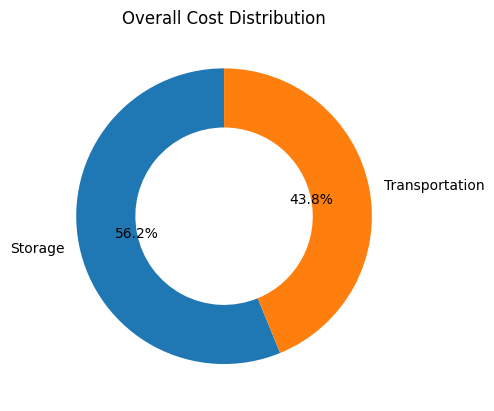

In [ ]:
#Vizualization of cost distribution
total_storage = df['Storage_Cost'].sum()
total_transport = df['Transportation_Cost'].sum()

plt.figure()

plt.pie(
    [total_storage, total_transport],
    labels=['Storage', 'Transportation'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title("Overall Cost Distribution")

plt.show()

In [ ]:
#Cost vs sales relationship
#Thresholds for cost and sales
cost_sales = (
    df.groupby('Warehouse_ID')
    .agg(
        total_cost=('total_cost', 'sum'),
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

median_cost = cost_sales['total_cost'].median()
median_sales = cost_sales['total_sales'].median()

In [ ]:
#Categorization
cost_sales['efficiency_category'] = np.select(
    [
        (cost_sales['total_cost'] > median_cost) & (cost_sales['total_sales'] <= median_sales),
        (cost_sales['total_cost'] <= median_cost) & (cost_sales['total_sales'] > median_sales),
        (cost_sales['total_cost'] > median_cost) & (cost_sales['total_sales'] > median_sales)
    ],
    [
        'High Cost - Low Sales (Inefficient)',
        'Low Cost - High Sales (Efficient)',
        'High Cost - High Sales'
    ],
    default='Low Cost - Low Sales'
)

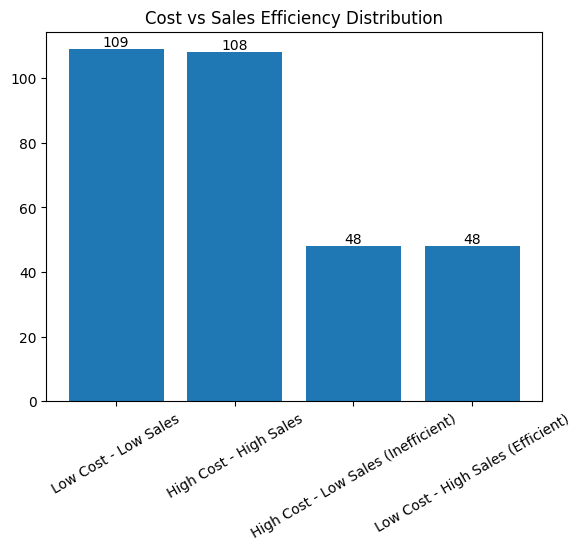

In [ ]:
eff_dist = cost_sales['efficiency_category'].value_counts()

plt.figure()

bars = plt.bar(eff_dist.index, eff_dist.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height),
             ha='center', va='bottom')

plt.xticks(rotation=30)
plt.title("Cost vs Sales Efficiency Distribution")

plt.show()

## Solution for the low cost high sales category

In [ ]:
# Warehouses in Low Cost - High Sales category
efficient_wh = cost_sales[
    cost_sales['efficiency_category'] == 'Low Cost - High Sales (Efficient)'
    
]
efficient_wh.sort_values(by='total_sales', ascending=False).head(10)

,Warehouse_ID,total_cost,total_sales,efficiency_category
126,WH199,20763,17076,Low Cost - High Sales (Efficient)
129,WH204,17953,16333,Low Cost - High Sales (Efficient)
228,WH375,19734,15851,Low Cost - High Sales (Efficient)
97,WH145,21604,14666,Low Cost - High Sales (Efficient)
190,WH307,21370,14246,Low Cost - High Sales (Efficient)
187,WH304,9132,9928,Low Cost - High Sales (Efficient)
120,WH191,18275,9842,Low Cost - High Sales (Efficient)
103,WH157,18877,9800,Low Cost - High Sales (Efficient)
67,WH097,13900,9762,Low Cost - High Sales (Efficient)
271,WH440,23685,9707,Low Cost - High Sales (Efficient)


In [ ]:
# Top 10 efficient warehouses based on highest sales
top_10_efficient_wh = (
    efficient_wh.sort_values(by='total_sales', ascending=False)
    .head(10)
)

In [ ]:
# Filter original data for only those top 10 warehouses
top_10_efficient_df = df.merge(
    top_10_efficient_wh[['Warehouse_ID']],
    on='Warehouse_ID',
    how='inner'
)

In [ ]:
# Warehouse details with location, supplier, and product category
top_10_efficient_details = (
    top_10_efficient_df.groupby(
        ['Warehouse_ID', 'Location', 'Supplier_ID', 'Product_Category']
    )
    .agg(
        total_sales=('Monthly_Sales', 'sum'),
        total_cost=('total_cost', 'sum')
    )
    .reset_index()
)

In [ ]:
# Sort so highest sales combinations appear first within each warehouse
top_10_efficient_details = top_10_efficient_details.sort_values(
    by=['Warehouse_ID', 'total_sales'],
    ascending=[True, False]
)
top_10_efficient_details

,Warehouse_ID,Location,Supplier_ID,Product_Category,total_sales,total_cost
0,WH097,Houston,S744,Electronics,9762,13900
1,WH145,Chicago,S392,Electronics,8757,14231
2,WH145,New York,S830,Groceries,5909,7373
3,WH157,Atlanta,S452,Apparel,9800,18877
4,WH191,Seattle,S136,Groceries,9842,18275
6,WH199,Miami,S158,Electronics,9527,9145
5,WH199,Atlanta,S319,Electronics,7549,11618
8,WH204,Seattle,S966,Electronics,8828,10794
7,WH204,New York,S364,Furniture,7505,7159
9,WH304,Los Angeles,S739,Furniture,9928,9132


In [ ]:
#Cost per unit - cpu
cpu = (
    df.groupby('Warehouse_ID')
    .agg(
        total_cost=('total_cost', 'sum'),
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

cpu['cost_per_unit'] = cpu['total_cost'] / cpu['total_sales']

In [ ]:
#Categorization
cpu['cpu_category'] = pd.cut(
    cpu['cost_per_unit'],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=[
        'Efficient',
        'Moderate',
        'High Cost',
        'Very High Cost'
    ]
)

In [ ]:
cpu.sort_values(by='cost_per_unit', ascending=False).head(10)

,Warehouse_ID,total_cost,total_sales,cost_per_unit,cpu_category
36,WH050,27706,1393,19.889447,Very High Cost
199,WH324,34110,1842,18.517915,Very High Cost
66,WH096,28252,1549,18.238864,Very High Cost
222,WH363,22824,1253,18.215483,Very High Cost
155,WH250,26751,1513,17.680767,Very High Cost
172,WH277,31328,1966,15.934893,Very High Cost
92,WH134,26962,1756,15.354214,Very High Cost
43,WH062,22460,1481,15.165429,Very High Cost
9,WH013,27291,2027,13.463740,Very High Cost
298,WH484,25186,1897,13.276753,Very High Cost


In [ ]:
#Category level cost
category_cost = (
    df.groupby('Product_Category')
    .agg(
        total_cost=('total_cost', 'sum'),
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

category_cost['cost_per_unit'] = (
    category_cost['total_cost'] / category_cost['total_sales']
)

category_cost.sort_values(by='cost_per_unit', ascending=False)
#almost same values across categories, no major cost differences at category level

,Product_Category,total_cost,total_sales,cost_per_unit
0,Apparel,2073558,564991,3.670073
1,Automotive,1723255,484459,3.557071
4,Groceries,1913444,541821,3.531506
3,Furniture,1676978,516458,3.247075
2,Electronics,1745225,560057,3.116156


In [ ]:
#Locaion level cost
location_cost = (
    df.groupby('Location')
    .agg(
        total_cost=('total_cost', 'sum'),
        total_sales=('Monthly_Sales', 'sum')
    )
    .reset_index()
)

location_cost['cost_per_unit'] = (
    location_cost['total_cost'] / location_cost['total_sales']
)

location_cost.sort_values(by='cost_per_unit', ascending=False)

,Location,total_cost,total_sales,cost_per_unit
9,Seattle,880200,190863,4.611685
5,Los Angeles,1027368,254419,4.038095
6,Miami,1033486,297266,3.476637
8,San Francisco,955229,279076,3.422827
3,Denver,852778,255713,3.334903
2,Dallas,891527,267824,3.328779
4,Houston,824040,248736,3.312910
0,Atlanta,1056160,324920,3.250523
7,New York,868290,287440,3.020770
1,Chicago,743382,261529,2.842446


In [ ]:
#Adding monthly revenue in the dataset
price_per_unit = 50
df['Monthly_Revenue'] = df['Monthly_Sales'] * price_per_unit

In [ ]:
#Profit 
profit_df = (
    df.groupby('Warehouse_ID')
    .agg(
        total_revenue=('Monthly_Revenue', 'sum'),
        total_cost=('total_cost', 'sum')
    )
    .reset_index()
)

In [ ]:
profit_df['profit'] = (
    profit_df['total_revenue'] - profit_df['total_cost']
)

In [ ]:
#finding profit margin
profit_df['profit_margin'] = (
    profit_df['profit'] / profit_df['total_revenue']
)

In [ ]:
#categorizing profit margin
profit_df['profit_category'] = pd.cut(
    profit_df['profit_margin'],
    bins=[-np.inf, 0.8, 0.9, 0.95, np.inf],
    labels=[
        'Low Margin',
        'Moderate',
        'High',
        'Very High'
    ]
)

In [ ]:
# Worst
profit_df.sort_values(by='profit_margin').head(10)

,Warehouse_ID,total_revenue,total_cost,profit,profit_margin,profit_category
36,WH050,69650,27706,41944,0.602211,Low Margin
199,WH324,92100,34110,57990,0.629642,Low Margin
66,WH096,77450,28252,49198,0.635223,Low Margin
222,WH363,62650,22824,39826,0.635690,Low Margin
155,WH250,75650,26751,48899,0.646385,Low Margin
172,WH277,98300,31328,66972,0.681302,Low Margin
92,WH134,87800,26962,60838,0.692916,Low Margin
43,WH062,74050,22460,51590,0.696691,Low Margin
9,WH013,101350,27291,74059,0.730725,Low Margin
298,WH484,94850,25186,69664,0.734465,Low Margin


## Solution: Setting benchmark for low margin warehouses

In [ ]:
# Warehouses with Very High profit margin
very_high_margin_wh = profit_df[
    profit_df['profit_category'] == 'Very High'
]

In [ ]:
# Top benchmark warehouses based on highest profit margin
benchmark_wh = (
    very_high_margin_wh.sort_values(by='profit_margin', ascending=False)
    .head(10)
)

In [ ]:
df = df.merge(
    profit_df[['Warehouse_ID', 'profit_margin']],
    on='Warehouse_ID',
    how='left'
)

In [ ]:
benchmark_details = (
    df.merge(
        benchmark_wh[['Warehouse_ID']],
        on='Warehouse_ID',
        how='inner'
    )
    .groupby('Warehouse_ID')
    .agg(
        Location=('Location', 'first'),
        Supplier_ID=('Supplier_ID', 'first'),
        top_category=('Product_Category', lambda x: x.mode()[0] if not x.mode().empty else None),
        avg_monthly_sales=('Monthly_Sales', 'mean'),
        avg_storage_cost=('Storage_Cost', 'mean'),
        avg_transport_cost=('Transportation_Cost', 'mean'),
        avg_profit_margin=('profit_margin', 'mean')
    )
    .reset_index()
)
benchmark_details

,Warehouse_ID,Location,Supplier_ID,top_category,avg_monthly_sales,avg_storage_cost,avg_transport_cost,avg_profit_margin
0,WH030,New York,S123,Apparel,9448.0,3341.0,6868.0,0.978389
1,WH032,Atlanta,S386,Furniture,9252.0,7872.0,1947.0,0.978774
2,WH112,Chicago,S669,Furniture,8079.0,2330.0,1930.0,0.989454
3,WH156,Los Angeles,S920,Apparel,8115.0,1110.0,5314.0,0.984168
4,WH220,Dallas,S271,Electronics,7295.0,2541.0,713.0,0.991079
5,WH264,Atlanta,S314,Electronics,7646.0,2827.0,5546.0,0.978098
6,WH304,Los Angeles,S739,Furniture,9928.0,2529.0,6603.0,0.981604
7,WH380,Denver,S873,Automotive,7556.0,2975.0,2045.0,0.986713
8,WH386,Chicago,S648,Groceries,7238.0,4079.0,1041.0,0.985852
9,WH453,New York,S434,Automotive,6710.0,4554.0,936.0,0.983636


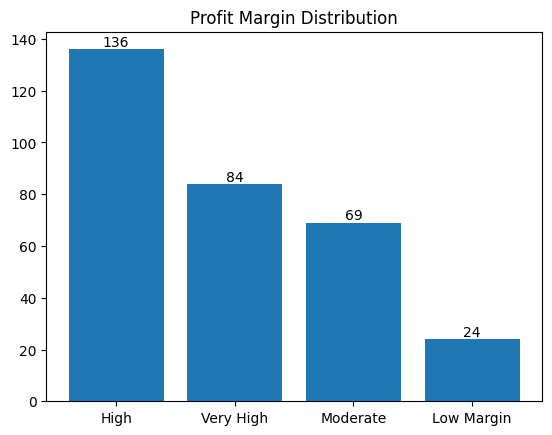

In [ ]:
#chart for profit margin distribution
profit_dist = profit_df['profit_category'].value_counts()

plt.figure()

bars = plt.bar(profit_dist.index, profit_dist.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height),
             ha='center', va='bottom')

plt.title("Profit Margin Distribution")

plt.show()

## Adding remaining features

In [ ]:
df['estimated_profit'] = df['Monthly_Revenue'] - df['total_cost']

In [ ]:
df['risk_score'] = (
    0.4 * df['Stockout_Risk'] +
    0.3 * df['Return_Rate'] +
    0.3 * df['damage_rate']
)

## Remaining vizualization

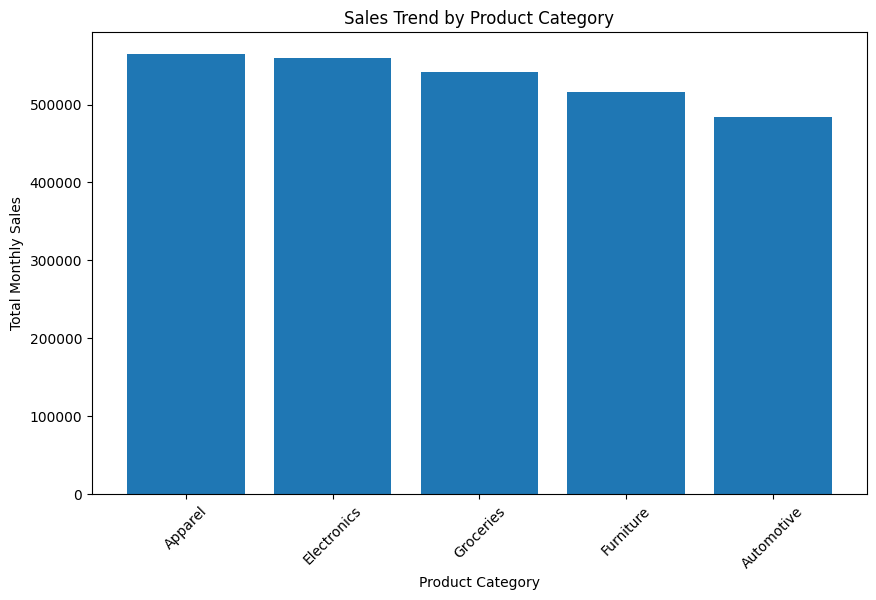

In [ ]:
# =========================
# 1. SALES TRENDS
# =========================

# Sales by Product Category
category_sales = (
    df.groupby('Product_Category')['Monthly_Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(category_sales.index, category_sales.values)
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Total Monthly Sales")
plt.title("Sales Trend by Product Category")
plt.show()

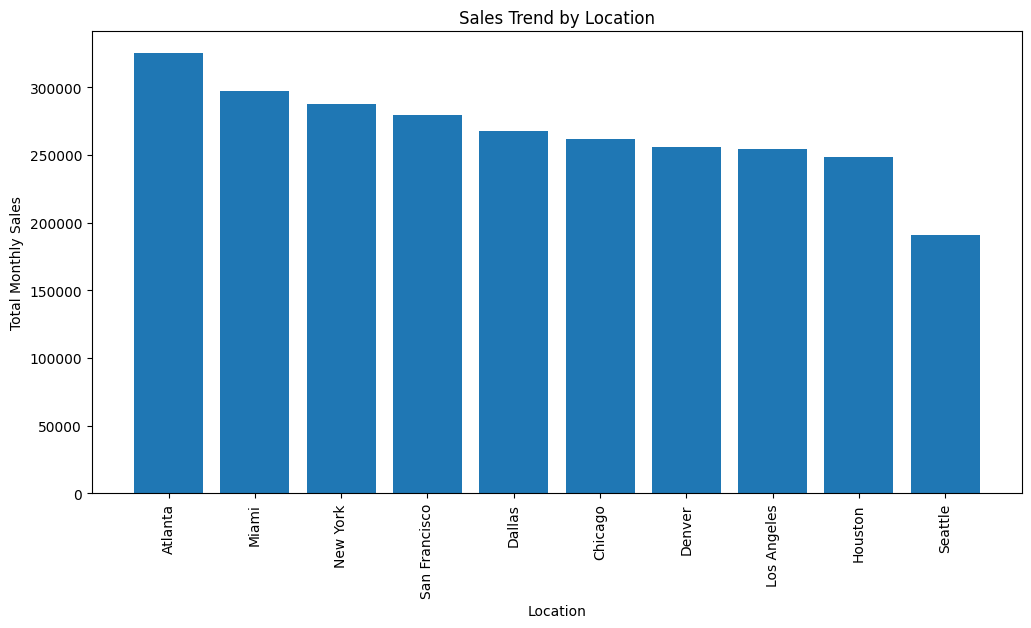

In [ ]:
# Sales by Location
location_sales = (
    df.groupby('Location')['Monthly_Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
plt.bar(location_sales.index, location_sales.values)
plt.xticks(rotation=90)
plt.xlabel("Location")
plt.ylabel("Total Monthly Sales")
plt.title("Sales Trend by Location")
plt.show()

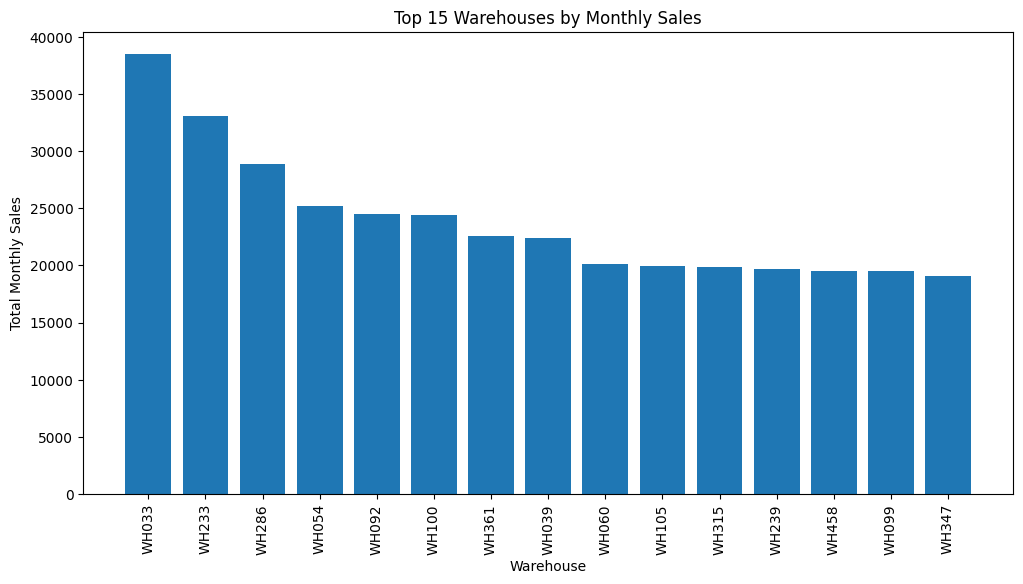

In [ ]:
# Top 15 Warehouses by Sales
warehouse_sales = (
    df.groupby('Warehouse_ID')['Monthly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
plt.bar(warehouse_sales.index, warehouse_sales.values)
plt.xticks(rotation=90)
plt.xlabel("Warehouse")
plt.ylabel("Total Monthly Sales")
plt.title("Top 15 Warehouses by Monthly Sales")
plt.show()

## Cost Analysis

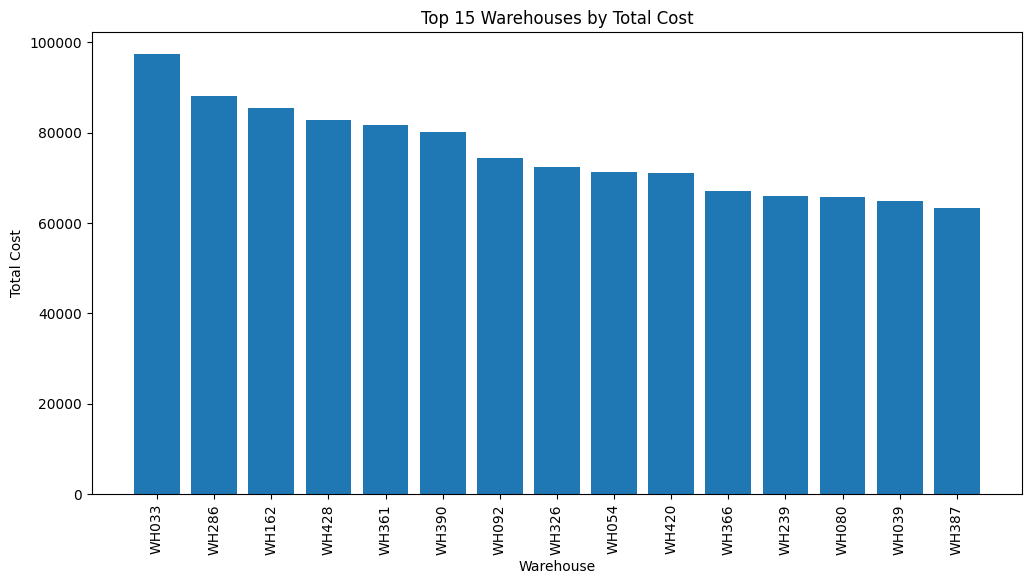

In [ ]:
# Top 15 Warehouses by Total Cost
warehouse_cost = (
    df.groupby('Warehouse_ID')['total_cost']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
plt.bar(warehouse_cost.index, warehouse_cost.values)
plt.xticks(rotation=90)
plt.xlabel("Warehouse")
plt.ylabel("Total Cost")
plt.title("Top 15 Warehouses by Total Cost")
plt.show()

## Delivery Efficiency

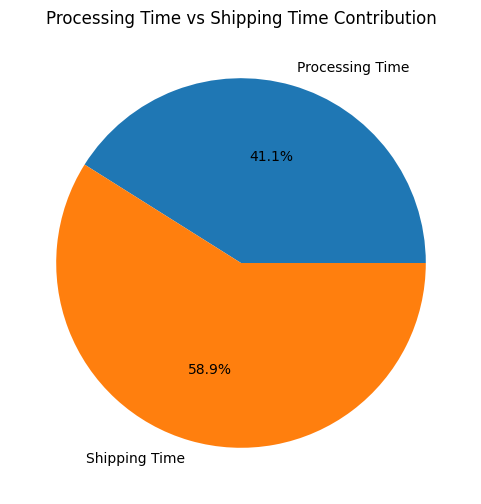

In [ ]:
# Processing Time vs Shipping Time
time_summary = df[['Order_Processing_Time', 'Shipping_Time_Days']].mean()

plt.figure(figsize=(6,6))
plt.pie(
    time_summary.values,
    labels=['Processing Time', 'Shipping Time'],
    autopct='%1.1f%%'
)
plt.title("Processing Time vs Shipping Time Contribution")
plt.show()

## Inventory Distribution

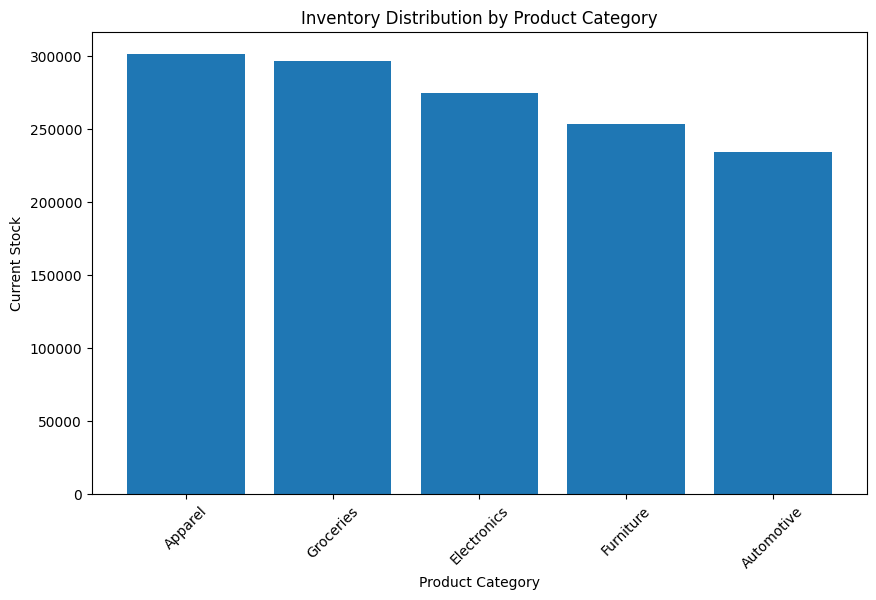

In [ ]:
# =========================
# 4. INVENTORY DISTRIBUTION
# =========================

# Inventory by Product Category
inventory_dist = (
    df.groupby('Product_Category')['Current_Stock']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(inventory_dist.index, inventory_dist.values)
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Current Stock")
plt.title("Inventory Distribution by Product Category")
plt.show()

In [ ]:
df['sales_per_employee']

0        58.951807
1       114.179487
2       121.551020
3       166.114286
4        34.014925
          ...     
495      60.917526
496      59.532468
497      27.852459
498     183.916667
499    1211.166667
Name: sales_per_employee, Length: 500, dtype: float64

In [ ]:
df['salary_cost'] = df['Operational_Cost'] - df['total_cost']

In [ ]:
df['salary_per_employee'] = df['salary_cost'] / df['Employee_Count']

In [ ]:
# Revenue handled per employee
df['revenue_per_employee'] = (
    df['Monthly_Revenue'] / df['Employee_Count']
)

In [ ]:
# Stock handled per employee
df['stock_per_employee'] = (
    df['Current_Stock'] / df['Employee_Count']
)

In [ ]:
# Benchmark productivity levels from top-performing warehouses
ideal_sales_per_employee = df['sales_per_employee'].median()
ideal_stock_per_employee = df['stock_per_employee'].median()

In [ ]:
# Estimate employee requirement from sales load
df['required_emp_sales'] = (
    df['Monthly_Sales'] / ideal_sales_per_employee
)

In [ ]:
# Estimate employee requirement from stock load
df['required_emp_stock'] = (
    df['Current_Stock'] / ideal_stock_per_employee
)

In [ ]:
# Final ideal employee count
df['ideal_employee_count'] = (
    (
        df['required_emp_sales'] +
        df['required_emp_stock']
    ) / 2
).round()

In [ ]:
df.head(15)

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,profit_margin,estimated_profit,risk_score,salary_cost,salary_per_employee,revenue_per_employee,stock_per_employee,required_emp_sales,required_emp_stock,ideal_employee_count
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,0.933010,224897,4.618172,74142,893.277108,2947.590361,47.301205,48.148340,77.162462,63.0
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,0.929993,207063,11.167682,31260,801.538462,5708.974359,77.743590,43.818630,59.591591,52.0
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,0.948027,274502,8.600737,40878,834.244898,6077.551020,97.204082,58.608525,93.613043,76.0
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,0.864258,260281,6.423317,8521,243.457143,8305.714286,63.400000,57.211209,43.612711,50.0
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,0.856669,93035,7.674925,13018,194.298507,1700.746269,12.074627,22.425928,15.900263,19.0
5,WH211,San Francisco,3840,666,9,1,19,30165,S459,Automotive,...,0.945866,55727,8.324759,19592,979.600000,3315.000000,192.000000,13.048171,75.472199,44.0
6,WH008,Atlanta,4757,4776,7,7,12,38284,S655,Apparel,...,0.948607,293404,6.060096,22388,238.170213,3290.425532,50.606383,60.871782,93.495118,77.0
7,WH438,Atlanta,4803,2432,9,5,20,45299,S845,Electronics,...,0.920438,245477,9.803604,13826,151.934066,3043.406593,52.780220,54.505141,94.399212,74.0
8,WH106,New York,1401,2940,10,6,22,36265,S456,Apparel,...,0.938969,73043,9.747836,18208,233.435897,1167.948718,17.961538,17.928934,27.535560,23.0
9,WH099,New York,4213,3732,5,7,20,57333,S569,Electronics,...,0.951303,217730,8.968831,44663,770.051724,3972.413793,72.637931,45.343869,82.803223,64.0


In [ ]:
#exporting the final df with all the new features to excel
df.to_excel("warehouse_analysis_final.xlsx", index=False)

In [ ]:
df.to_csv("warehouse_analysis_final.csv", index=False)

In [ ]:
df

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,profit_margin,estimated_profit,risk_score,salary_cost,salary_per_employee,revenue_per_employee,stock_per_employee,required_emp_sales,required_emp_stock,ideal_employee_count
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,0.933010,224897,4.618172,74142,893.277108,2947.590361,47.301205,48.148340,77.162462,63.0
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,0.929993,207063,11.167682,31260,801.538462,5708.974359,77.743590,43.818630,59.591591,52.0
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,0.948027,274502,8.600737,40878,834.244898,6077.551020,97.204082,58.608525,93.613043,76.0
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,0.864258,260281,6.423317,8521,243.457143,8305.714286,63.400000,57.211209,43.612711,50.0
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,0.856669,93035,7.674925,13018,194.298507,1700.746269,12.074627,22.425928,15.900263,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH145,New York,4357,1521,10,5,20,65281,S830,Groceries,...,0.970539,288077,9.636525,57908,596.989691,3045.876289,44.917526,58.146033,85.633430,72.0
496,WH181,Miami,3110,3322,4,7,8,88426,S663,Groceries,...,0.905084,215594,3.638653,74820,971.688312,2976.623377,40.389610,45.107703,61.124620,53.0
497,WH068,Seattle,1636,4170,4,3,6,87751,S961,Apparel,...,0.962702,69530,4.949215,72331,1185.754098,1392.622951,26.819672,16.718584,32.154302,24.0
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,...,0.978016,430606,11.306011,67435,1404.895833,9195.833333,37.937500,86.869721,35.790332,61.0
